In [1]:
# =============================================================================
#                                LIBRERIE
# =============================================================================
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import geopandas as gpd
import urllib.request
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
from IPython.display import display
from matplotlib.ticker import FixedLocator, FixedFormatter # <--- IMPORT FONDAMENTALE
import warnings
warnings.filterwarnings('ignore')

%%HTML
<style>
    /* --- RESET DI BASE --- */
    .reveal .slides section {
        /* Forza la slide a occupare tutto lo spazio e ad allineare verticalmente */
        height: 100% !important;
        display: flex !important;
        flex-direction: column !important;
        justify-content: flex-start !important; /* Inizia dall'alto */
        align-items: center !important; /* Centra orizzontalmente */
        padding: 0 !important;
    }

    /* --- GESTIONE TITOLI --- */
    /* Riduciamo i margini dei titoli per lasciare spazio al grafico */
    .reveal h1, .reveal h2, .reveal h3 {
        margin-top: 20px !important;
        margin-bottom: 10px !important;
        flex-shrink: 0; /* Impedisce al titolo di schiacciarsi */
    }
    
    /* Il testo descrittivo sotto il titolo */
    .reveal p {
        margin: 0 0 10px 0 !important;
        flex-shrink: 0;
    }

    /* --- GESTIONE IMMAGINI/GRAFICI --- */
    /* Il contenitore del grafico */
    .jp-OutputArea-output, 
    .reveal div.output_subarea {
        flex-grow: 1; /* Occupa tutto lo spazio verticale rimanente */
        display: flex !important;
        align-items: center !important; /* Centra verticalmente nel suo spazio */
        justify-content: center !important;
        width: 100% !important;
        overflow: hidden !important; /* Niente barre di scorrimento */
        margin: 0 !important;
        padding: 0 !important;
    }

    /* L'immagine vera e propria */
    .jp-RenderedImage img, 
    .reveal div.output_subarea img {
        /* LE REGOLE D'ORO PER NON TAGLIARE MAI */
        width: auto !important;
        height: auto !important;
        
        /* Limiti massimi dinamici */
        max-width: 90% !important;  
        max-height: 65vh !important; /* Usa max il 65% dell'altezza schermo */
        
        /* Assicura che l'intera immagine sia visibile dentro i limiti */
        object-fit: contain !important; 
        
        background-color: white !important;
        border-radius: 6px !important;
        box-shadow: none !important;
    }

    /* Nascondi input e prompt */
    .jp-InputArea, .jp-OutputPrompt, .jp-Cell-inputWrapper {
        display: none !important;
    }
    /* Ma mostra il testo markdown */
    .jp-MarkdownCell .jp-InputArea, .jp-MarkdownCell .jp-Cell-inputWrapper {
        display: block !important;
    }
</style>

In [2]:
# =============================================================================
#                                CONFIGURAZIONE
# =============================================================================

sns.set_theme(style="darkgrid")
asseX_stagioneCalcistica = "Stagione Calcistica (AA/AA)"
asseY_prezzoMld = "Prezzo (Mld €)"

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

CART_DATI = os.path.join(BASE_DIR, "..", "Dataset")
CART_GRAFICI = os.path.join(BASE_DIR, "..", "Grafici")
FILE_TRASFERIMENTI = os.path.join(CART_DATI, "transfers.csv")
FILE_CLUBS = os.path.join(CART_DATI, "clubs.csv")
FILE_GIOCATORI = os.path.join(CART_DATI, "players.csv")
FILE_PARTITE = os.path.join(CART_DATI, "games.csv")
FILE_APPARENZE = os.path.join(CART_DATI, "appearances.csv")

# STAGIONI DI INTERESSE
STAGIONI_TARGET = [
    '10/11', '11/12', '12/13', '13/14', '14/15', '15/16', '16/17', 
    '17/18', '18/19', '19/20', '20/21', '21/22', '22/23', '23/24'
]

PREZZO_MINIMO = 5000000 # 5 milioni 

if not os.path.exists(CART_GRAFICI):
    os.makedirs(CART_GRAFICI)
    print(f"[SETUP] Creata cartella grafici: {CART_GRAFICI}")

In [3]:
# =============================================================================
#                       GESTIONE DATI
# =============================================================================

def carica_dati(percorso_file):
    """Carica il csv e restituisce il DataFrame o None."""
    if os.path.exists(percorso_file):
        print(f"[INFO] Caricamento: {percorso_file}...")
        return pd.read_csv(percorso_file)
    else:
        print(f"[ERROR] File non trovato: {percorso_file}")
        return None

def pulisci_trasferimenti(df):
    """Pulisce i NaN e prepara i tipi di dato."""
    if df is None:
        raise ValueError("DataFrame vuoto passato a pulisci_trasferimenti")
    
    df_clean = df.copy()
    df_clean['transfer_fee'] = df_clean['transfer_fee'].fillna(0.0)
    df_clean['market_value_in_eur'] = df_clean['market_value_in_eur'].fillna(0.0)
    return df_clean

def calcola_metriche_annuali(df):
    """Aggrega i dati per stagione."""
    df_work = df.copy()
    
    try:
        df_work['Anno'] = df_work['transfer_season'].str.slice(0, 2).astype(int) + 2000
    except Exception:
        df_work['Anno'] = pd.to_numeric(df_work['transfer_season'].str.slice(0, 2), errors='coerce') + 2000
        
    df_filt = df_work[df_work['Anno'].between(2010, 2023)].dropna(subset=['Anno']).copy()
    
    df_agg = df_filt.groupby('transfer_season').agg(
        Valore_Totale_EURO=('market_value_in_eur','sum'),
        Spesa_Totale_EUR=('transfer_fee', 'sum'),
        Volume_Trasferimenti=('player_id', 'count')
    ).reset_index()

    df_agg.rename(columns={'transfer_season': 'Anno-Calcistico'}, inplace=True)
    df_agg['Spesa_Mld_EUR'] = df_agg['Spesa_Totale_EUR'] / 1e9
    df_agg['Valore_Totale_Mld_EURO'] = df_agg['Valore_Totale_EURO'] / 1e9
    
    return df_agg

def aggiungi_spesa_reale(df_agg):
    """Calcola l'inflazione interna del mercato."""
    df = df_agg.copy()
    spesa_euro = df['Spesa_Mld_EUR'] * 1e9
    df['Costo_Medio_Unitario'] = spesa_euro / df['Volume_Trasferimenti']
    
    # Anno base: ultima entry
    costo_base = df.iloc[-1]['Costo_Medio_Unitario']
    df['Spesa_Reale_Mld_EUR'] = df['Spesa_Mld_EUR'] * (costo_base / df['Costo_Medio_Unitario'])
    return df

def analizza_efficienza(df_raw, stagioni_target):
    """Analisi avanzata efficienza mercato (delta valore/prezzo)."""
    df = df_raw[df_raw['transfer_season'].isin(stagioni_target)].copy()
    df = df[df['transfer_fee'] > 0]
    
    df_agg = df.groupby('transfer_season').agg(
        Valore_Totale_EURO=('market_value_in_eur', 'sum'),
        Spesa_Totale_EUR=('transfer_fee', 'sum')
    ).reset_index()
    
    df_agg.rename(columns={'transfer_season': 'Anno-Calcistico'}, inplace=True)
    df_agg['Spesa_Mld_EUR'] = df_agg['Spesa_Totale_EUR'] / 1e9
    df_agg['Valore_Totale_Mld_EURO'] = df_agg['Valore_Totale_EURO'] / 1e9
    
    df_agg['Delta_Assoluto'] = df_agg['Spesa_Mld_EUR'] - df_agg['Valore_Totale_Mld_EURO']
    df_agg['Premium_Percentuale'] = (df_agg['Delta_Assoluto'] / df_agg['Valore_Totale_Mld_EURO']) * 100

    df_agg['Anno-Calcistico'] = pd.Categorical(df_agg['Anno-Calcistico'], categories=stagioni_target, ordered=True)
    return df_agg.sort_values('Anno-Calcistico')

def calcola_correlazione(df, col_x, col_y):
    """Calcolo coefficiente di Pearson e P-value"""
    return pearsonr(df[col_x], df[col_y])

def calcola_inflazione(df_raw, soglia_minima=PREZZO_MINIMO):
    print("[INFO] Calcolo Indice di Inflazione su TUTTO il mercato...")
    
    try:
        df_raw['Anno_Sort'] = df_raw['transfer_season'].str.slice(0, 2).astype(int) + 2000
    except:
        df_raw['Anno_Sort'] = pd.to_numeric(df_raw['transfer_season'].str.slice(0, 2), errors='coerce') + 2000
    
    df_market = df_raw[(df_raw['transfer_fee'] > 500000) & (df_raw['Anno_Sort'].between(2010, 2023))].copy()
    
    paniere = df_market.groupby('transfer_season').agg(
        Prezzo_Mediano=('transfer_fee', 'median')
    ).reset_index().sort_values('transfer_season')

    valore_base = paniere.iloc[0]['Prezzo_Mediano']
    paniere['Indice_Inflazione'] = paniere['Prezzo_Mediano'] / valore_base
    
    df_analysis = df_raw[df_raw['transfer_fee'] >= soglia_minima].copy()
    df_analysis = df_analysis[df_analysis['Anno_Sort'].between(2010, 2023)]
    
    spesa = df_analysis.groupby('transfer_season')['transfer_fee'].sum().reset_index()
    spesa.rename(columns={'transfer_fee': 'Spesa_Nominale'}, inplace=True)
    
    df_fin = pd.merge(spesa, paniere, on='transfer_season', how='left')
    
    df_fin['Spesa_Mld_EUR'] = df_fin['Spesa_Nominale'] / 1e9
    df_fin['Spesa_Reale_Mld_EUR'] = df_fin['Spesa_Mld_EUR'] / df_fin['Indice_Inflazione']
    df_fin.rename(columns={'transfer_season': 'Anno-Calcistico'}, inplace=True)
    
    return df_fin

def prepara_dati_eta_valore(df_prov):
    """
    Prepara il dataset giocatori per analisi Età
    filtro per giocatori con contratto e valore soglia minima
    prendo in considerazione i giocatori tra i 18 anni e i 33 anni 
    (anni successivi trascurabili in quanto pochi movimenti sopra i 5 milioni e spesso a parametro zero)
    """
    print("\n[ETÀ-VALORE] --- INIZIO DIAGNOSTICA ---")
    
    if df_prov is None:
        print("[ERROR] DataFrame iniziale vuoto.")
        return pd.DataFrame()

    df = df_prov.copy()

    if df['market_value_in_eur'].dtype == object:
        df['market_value_in_eur'] = df['market_value_in_eur'].astype(str).str.replace(',', '', regex=False)

    df['market_value_in_eur'] = pd.to_numeric(df['market_value_in_eur'], errors='coerce')
    df = df.dropna(subset=['market_value_in_eur'])
    
    df['contract_expiration_date'] = pd.to_datetime(df['contract_expiration_date'], errors='coerce')
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    
    data_limite = pd.to_datetime('2023-06-30')

    df = df[
        (df['contract_expiration_date'] >= data_limite) & 
        (df['market_value_in_eur'] > PREZZO_MINIMO)
    ].copy()

    print(f" -> Giocatori ritenuti attivi (con contratto o Top Player): {len(df)}")
    
    target_date = pd.to_datetime('2024-01-01') 
    df['age'] = (target_date - df['date_of_birth']).dt.days // 365
    
    df = df[df['market_value_in_eur'] >= PREZZO_MINIMO]
    df = df[df['age'].between(18, 32)]
    df['Valore_Mln'] = df['market_value_in_eur'] / 1e6

    print(f" -> Dataset finale pronto: {len(df)} giocatori.")
    
    return df[['player_id', 'age', 'Valore_Mln', 'market_value_in_eur', 'current_club_domestic_competition_id']]

def prepara_dati_eta_valore_totale(df_prov):
    """
    Prepara il dataset giocatori per analisi Età
    filtro per giocatori con contratto e valore soglia minima
    prendo in considerazione i giocatori tra i 18 anni e i 33 anni 
    (anni successivi trascurabili in quanto pochi movimenti sopra i 5 milioni e spesso a parametro zero)
    """
    print("\n[ETÀ-VALORE] --- INIZIO DIAGNOSTICA ---")
    
    if df_prov is None:
        print("[ERROR] DataFrame iniziale vuoto.")
        return pd.DataFrame()

    df = df_prov.copy()

    if df['market_value_in_eur'].dtype == object:
        df['market_value_in_eur'] = df['market_value_in_eur'].astype(str).str.replace(',', '', regex=False)

    df['market_value_in_eur'] = pd.to_numeric(df['market_value_in_eur'], errors='coerce')
    df = df.dropna(subset=['market_value_in_eur'])
    
    df['contract_expiration_date'] = pd.to_datetime(df['contract_expiration_date'], errors='coerce')
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    
    data_limite = pd.to_datetime('2023-06-30')

    df = df[
        (df['contract_expiration_date'] >= data_limite) & 
        (df['market_value_in_eur'] > PREZZO_MINIMO)
    ].copy()

    print(f" -> Giocatori ritenuti attivi (con contratto o Top Player): {len(df)}")
    
    target_date = pd.to_datetime('2024-01-01') 
    df['age'] = (target_date - df['date_of_birth']).dt.days // 365
    
    df = df[df['market_value_in_eur'] >= PREZZO_MINIMO]
    df = df[df['age'].between(15, 40)]
    df['Valore_Mln'] = df['market_value_in_eur'] / 1e6

    print(f" -> Dataset finale pronto: {len(df)} giocatori.")
    
    return df[['player_id', 'age', 'Valore_Mln', 'market_value_in_eur', 'current_club_domestic_competition_id']]

def crea_dizionario(df_analisi):
    """
    Creo il dizionario valore-età
    - valore: soglia baffo superiore (per evidenziare outlier)
    - età (età calcolata sul 2024)
    """
    print("--- CALCOLO SOGLIE STATISTICHE (BAFFI) ---")
    mappa_soglie = {}
    
    for eta in range(18, 33):
        gruppo = df_analisi[df_analisi['age'] == eta]
        if len(gruppo) < 5: continue
            
        Q1 = gruppo['Valore_Mln'].quantile(0.25)
        Q3 = gruppo['Valore_Mln'].quantile(0.75)
        IQR = Q3 - Q1
        baffo_superiore = Q3 + (1.5 * IQR)
        mappa_soglie[eta] = round(baffo_superiore, 2)
        
    print(f"[OK] Calcolate le soglie per {len(mappa_soglie)} fasce d'età.")
    return mappa_soglie

def estrai_outlier_eta(df_clean, df_anagrafica):
    """
    Estrazione Outlier grafico età - valore
    """
    print("\n--- ESTRAZIONE E VISUALIZZAZIONE PER ETÀ ---")
    
    lista_risultati = []
    mappa_soglie = crea_dizionario(df_clean)

    for eta, soglia in mappa_soglie.items():
        outliers_ids = df_clean[
            (df_clean['age'] == eta) & 
            (df_clean['Valore_Mln'] > soglia)
        ]['player_id'].unique()
        
        if len(outliers_ids) == 0: continue
            
        dettagli = df_anagrafica[df_anagrafica['player_id'].isin(outliers_ids)].copy()
        
        dettagli['Età_Analisi'] = eta
        dettagli['Soglia_Baffo'] = soglia
        
        if 'market_value_in_eur' in dettagli.columns:
            dettagli['Valore_Mln_Reale'] = dettagli['market_value_in_eur'] / 1e6
            dettagli['Extra_Valore'] = dettagli['Valore_Mln_Reale'] - soglia
        
        lista_risultati.append(dettagli)

    if not lista_risultati:
        print("Nessun giocatore trovato.")
        return pd.DataFrame()

    df_completo = pd.concat(lista_risultati)
    
    if 'last_season' in df_completo.columns:
        df_completo['last_season'] = pd.to_numeric(df_completo['last_season'], errors='coerce')
        max_season = df_completo['last_season'].max()
        
        print(f"[FILTRO] Tengo stagioni: {max_season} e {max_season - 1}")
        df_completo = df_completo[df_completo['last_season'] >= (max_season - 1)]

    eta_presenti = sorted(df_completo['Età_Analisi'].unique())
    
    cols_output = ['name', 'Valore_Mln_Reale', 'Soglia_Baffo', 'Extra_Valore', 'current_club_name', 'last_season']
    
    if 'name' not in df_completo.columns and 'player_name' in df_completo.columns:
        cols_output[0] = 'player_name'
        
    cols_reali = [c for c in cols_output if c in df_completo.columns]

    for eta in eta_presenti:
        df_subset = df_completo[df_completo['Età_Analisi'] == eta].copy()
        df_subset = df_subset.sort_values(by='Valore_Mln_Reale', ascending=False)
        
        print(f"-"*80 + "\n" + f"OUTLIER PER {eta} ANNI (Soglia > {mappa_soglie[eta]} Mln €)" + "\n" + f"-"*80)
        display(df_subset[cols_reali]) 
        print("\n")

    return

def analizza_efficienza(df_raw, stagioni_target):
    """Analisi avanzata efficienza mercato (delta valore/prezzo)."""
    df = df_raw[df_raw['transfer_season'].isin(stagioni_target)].copy()
    df = df[df['transfer_fee'] > 0] 
    
    df_agg = df.groupby('transfer_season').agg(
        Valore_Totale_EURO=('market_value_in_eur', 'sum'),
        Spesa_Totale_EUR=('transfer_fee', 'sum')
    ).reset_index()
    
    df_agg.rename(columns={'transfer_season': 'Anno-Calcistico'}, inplace=True)
    df_agg['Spesa_Mld_EUR'] = df_agg['Spesa_Totale_EUR'] / 1e9
    df_agg['Valore_Totale_Mld_EURO'] = df_agg['Valore_Totale_EURO'] / 1e9
    
    df_agg['Delta_Assoluto'] = df_agg['Spesa_Mld_EUR'] - df_agg['Valore_Totale_Mld_EURO']
    df_agg['Premium_Percentuale'] = (df_agg['Delta_Assoluto'] / df_agg['Valore_Totale_Mld_EURO']) * 100
    
    df_agg['Anno-Calcistico'] = pd.Categorical(df_agg['Anno-Calcistico'], categories=stagioni_target, ordered=True)
    return df_agg.sort_values('Anno-Calcistico')

def plot_risultati_attaccanti(df_analyzed):
    """
    Genera lo scatterplot Reale vs Fair Value con assi logaritmici DETTAGLIATI.
    Usa FixedLocator per forzare Matplotlib a obbedire ai tick manuali.
    """
    print("[PLOT] Generazione grafico con scaglioni FORZATI (Metodo FixedLocator)...")
    
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    ax = sns.scatterplot(
        data=df_analyzed,
        x='predicted_fee',
        y='transfer_fee',
        hue='status',
        palette={'Overpaid': '#d64541', 'Value Deal': '#27ae60'},
        legend=False, 
        alpha=0.75,
        s=80,
        edgecolor='w'
    )

    max_val = max(df_analyzed['predicted_fee'].max(), df_analyzed['transfer_fee'].max())
    plt.plot([0, max_val], [0, max_val], color='#2c3e50', linestyle='--', linewidth=2)

    ax.set_xscale('log')
    ax.set_yscale('log')

  
    custom_ticks = [500000, 1000000, 2000000, 5000000, 10000000, 20000000, 50000000, 100000000]
    custom_labels = ['€0.5M', '€1M', '€2M', '€5M', '€10M', '€20M', '€50M', '€100M']

    ax.xaxis.set_major_locator(FixedLocator(custom_ticks))
    ax.xaxis.set_major_formatter(FixedFormatter(custom_labels))
    
    ax.yaxis.set_major_locator(FixedLocator(custom_ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(custom_labels))

    ax.minorticks_off()

    ax.set_xlim(400000, 150000000)
    ax.set_ylim(400000, 150000000)
    
    plt.xlabel('Valore Stimato (Mln €)', fontsize=12, fontweight='bold')
    plt.ylabel('Prezzo Reale (Mln €)', fontsize=12, fontweight='bold')

    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'valore_mercato_attaccanti.png'))

def focusVerde(df_efficienza_full):
    stagioni_focus = ['20/21', '21/22', '22/23'] 
    df_focus = df_efficienza_full[df_efficienza_full['Anno-Calcistico'].isin(stagioni_focus)].copy()
    df_focus['Anno-Calcistico'] = pd.Categorical(
        df_focus['Anno-Calcistico'], 
        categories=stagioni_focus, 
        ordered=True
    )
    return df_focus.sort_values('Anno-Calcistico')

def prepara_dati_heatmap(df_valori, df_anagrafica):
    """
    Esegue il merge, la traduzione dei ruoli
    e la creazione della pivot table ordinata.
    Restituisce la matrice pronta per il plotting.
    """

    df_merged = df_valori.merge(
        df_anagrafica[['player_id', 'position']], 
        on='player_id', 
        how='inner'
    )

    dizionario_ruoli = {
        'Goalkeeper': 'Portiere',
        'Defender': 'Difensore',
        'Centre-Back': 'Difensore',
        'Left-Back': 'Difensore',
        'Right-Back': 'Difensore',
        'Midfield': 'Centrocampista', 
        'Midfielder': 'Centrocampista',
        'Defensive Midfield': 'Centrocampista',
        'Attacking Midfield': 'Centrocampista',
        'Attack': 'Attaccante',
        'Forward': 'Attaccante',
        'Striker': 'Attaccante',
        'Winger': 'Attaccante',
        'Left Winger': 'Attaccante',
        'Right Winger': 'Attaccante'
    }
    
    df_merged['Ruolo_ITA'] = df_merged['position'].replace(dizionario_ruoli)
    bins = [0, 20, 23, 26, 29, 32, 100]
    labels = ['<20', '21-23', '24-26', '27-29', '30-32', '33+']
    df_merged['fascia_eta'] = pd.cut(df_merged['age'], bins=bins, labels=labels)
    matrix = df_merged.pivot_table(
        index='Ruolo_ITA', 
        columns='fascia_eta', 
        values='Valore_Mln', 
        aggfunc='mean'
    )
    ordine_logico = ['Attaccante', 'Centrocampista', 'Difensore', 'Portiere']

    ordine_presente = [r for r in ordine_logico if r in matrix.index]

    altri_ruoli = [r for r in matrix.index if r not in ordine_presente]
    
    matrix = matrix.reindex(ordine_presente + altri_ruoli)
    
    return matrix

In [4]:
# =============================================================================
#                       GRAFICI
# =============================================================================

def visualizza_salva_grafico(fig, path_completo):
    """Funzione helper salvataggio."""
    try:
        plt.tight_layout()
        fig.savefig(path_completo)
        plt.show()
    except Exception as e:
        print(f"[GRAFICO - ERROR] Impossibile salvare il grafico: {e}")

def plot_confronto_nominale_reale(df, cartella_output):
    """Confronto tra spesa reale e spesa inflazionata."""
    plt.figure(figsize=(12, 7))
    
    sns.lineplot(
        data=df, 
        x='Anno-Calcistico', 
        y='Spesa_Mld_EUR', 
        label='Spesa Nominale', 
        marker='o', color='red', linestyle='--', alpha=0.6, linewidth=2
    )

    sns.lineplot(
        data=df, 
        x='Anno-Calcistico', 
        y='Spesa_Reale_Mld_EUR', 
        label='Spesa Reale', 
        marker='o', color='gray', linewidth=3
    )

    plt.fill_between(
        df['Anno-Calcistico'], 
        df['Spesa_Mld_EUR'], 
        df['Spesa_Reale_Mld_EUR'], 
        color='red', alpha=0.1
    )

    plt.ylabel(asseY_prezzoMld, fontsize=12, fontweight='bold')
    plt.xlabel(asseX_stagioneCalcistica, fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend()
    
    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'confronto_inflazione_reale.png'))

def correlazione_volume_spesa(df, r, p, cartella_output):
    """Scatterplot correlazione volume"""
    colonna_x = 'Volume_Trasferimenti'
    colonna_y = 'Spesa_Mld_EUR'
    colonna_label = 'Anno-Calcistico'

    # 1. Assicurati che il DataFrame sia ordinato cronologicamente
    df = df.sort_values(by=colonna_label).reset_index(drop=True)

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # Disegniamo prima la linea di regressione disattivando lo scatter di default
    sns.regplot(
        data=df,
        x=colonna_x,
        y=colonna_y,
        ci=None,
        scatter=False, 
        line_kws={'color': '#d62728', 'linestyle': '--', 'linewidth': 2.5, 'label': f'Trend Lineare ($R={r:.2f}$)'}
    )

    # 2. Creiamo lo scatterplot con una colormap sequenziale (es. tonalità di blu)
    # I punti più chiari sono i più vecchi, i più scuri sono i più recenti
    scatter = plt.scatter(
        df[colonna_x], 
        df[colonna_y], 
        c=df.index, # Usa l'indice ordinato per definire l'intensità del colore
        cmap='Blues', 
        s=200, 
        alpha=0.9, 
        edgecolor='black', # Bordo nero per maggior contrasto al posto del bianco
        linewidths=1.5,
        zorder=5 # Mantiene i punti sopra la linea di regressione
    )

    y_range = df[colonna_y].max() - df[colonna_y].min()
    offset = y_range * 0.035 

    # 3. FIX: Estrazione e stampa della label corretta
    for i in range(df.shape[0]):
        x_val = df[colonna_x].iloc[i]
        y_val = df[colonna_y].iloc[i]
        label_anno = str(df[colonna_label].iloc[i]) # Estrae l'anno
        
        plt.text(
            x_val, 
            y_val - offset, 
            label_anno, # Sostituita la stringa vuota con il dato reale
            color='black', 
            fontsize=10, 
            fontweight='bold', 
            ha='center', 
            va='top', 
            alpha=0.8
        )

    plt.xlabel('Volume Trasferimenti (n acquisti)', fontsize=13, fontweight='bold')
    plt.ylabel('Spesa Totale (Mld €)', fontsize=13, fontweight='bold')
    plt.legend(loc='lower right', frameon=True, fontsize=12, facecolor='white', framealpha=1)
    
    # Assicurati di avere importato 'os' e definito 'CART_GRAFICI' o usa il parametro 'cartella_output'
    percorso_salvataggio = os.path.join(cartella_output, 'scatterplot_finale_clean_labeled.png')
    visualizza_salva_grafico(plt, percorso_salvataggio)

def plot_istogramma_spese(df, cartella_output):
    """Istogramma spese annuali."""
    anni = df['Anno-Calcistico']
    spese = df['Spesa_Mld_EUR']

    plt.figure(figsize=(12, 7)) 
    bars = plt.bar(anni, spese, color='skyblue', label='Spesa (Mld EUR)')

    plt.xlabel(asseX_stagioneCalcistica, fontsize=12, fontweight='bold')
    plt.ylabel(asseY_prezzoMld, fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='center', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + (spese.max() * 0.01),
            "",
            ha='center', va='bottom', fontsize=9
        )

    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'spese_annuali_istogramma.png'))

def plot_trend_efficienza(df_plot, cartella_output):
    """Trend efficienza con doppia area di riempimento."""
    plt.figure(figsize=(14, 7))
    
    sns.lineplot(data=df_plot, x='Anno-Calcistico', y='Spesa_Mld_EUR', 
                 marker='o', label='Spesa Nominale', color='red', linestyle='--', linewidth=3)
    
    sns.lineplot(data=df_plot, x='Anno-Calcistico', y='Valore_Totale_Mld_EURO', 
                 marker='o', label='Valore Stimato', color='#1D3557', linewidth=3)
    
    plt.fill_between(df_plot['Anno-Calcistico'], 
                     df_plot['Valore_Totale_Mld_EURO'], 
                     df_plot['Spesa_Mld_EUR'], 
                     where=(df_plot['Spesa_Mld_EUR'] > df_plot['Valore_Totale_Mld_EURO']),
                     interpolate=True, color='#E63946', alpha=0.15, label='Overspending')
    
    plt.fill_between(df_plot['Anno-Calcistico'], 
                     df_plot['Valore_Totale_Mld_EURO'], 
                     df_plot['Spesa_Mld_EUR'], 
                     where=(df_plot['Spesa_Mld_EUR'] <= df_plot['Valore_Totale_Mld_EURO']),
                     interpolate=True, color='green', alpha=0.15, label='Underspending')

    plt.ylabel(asseY_prezzoMld, fontsize=12, fontweight='bold')
    plt.xlabel(asseX_stagioneCalcistica, fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9)
    plt.xticks(rotation=45)
    
    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'trend_spesa_valore.png'))

def plot_distribuzione_eta_valore(df, cartella_output):
    """
    Scala logaritmica
    """
    if df.empty:
        print("[WARN] Dataset vuoto. Impossibile generare grafico.")
        return

    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")

    # Creazione Boxplot
    ax = sns.boxplot(
        data=df, 
        x='age', 
        y='Valore_Mln', 
        palette='mako',        
        linewidth=1.2,
        showfliers=True,
        flierprops={"marker": "d", "markerfacecolor": "#555", "markersize": 3, "alpha": 0.5}
    )

    # --- SCALA LOGARITMICA --- (RICORDA)
    ax.set_yscale("log")

    custom_ticks = [5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]
    ax.set_yticks(custom_ticks)
    

    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

    ax.set_ylim(bottom=4.5, top=df['Valore_Mln'].max() * 1.1)
    plt.xlabel("Età (Anni)", fontsize=14, fontweight='bold')
    plt.ylabel("Valore di Mercato (Mln €)", fontsize=14, fontweight='bold')
    
    plt.grid(True, which="major", axis="y", ls="--", alpha=0.5)
   
    mediana_per_eta = df.groupby('age')['Valore_Mln'].median()
    peak_age = mediana_per_eta.idxmax()
    peak_val = mediana_per_eta.max()

    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'boxplot_eta_valore_log.png'))

def plot_risultati_attaccanti(df_analyzed):
    """
    Genera lo scatterplot Reale vs Fair Value con colori rosso/verde.
    """
    print("[PLOT] Generazione grafico...")
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    sns.scatterplot(
        data=df_analyzed,
        x='predicted_fee',
        y='transfer_fee',
        hue='status',
        palette={'Overpaid': '#d64541', 'Value Deal': '#27ae60'},
        legend=False,
        alpha=0.75,
        s=80,
        edgecolor='w'
    )

    max_val = max(df_analyzed['predicted_fee'].max(), df_analyzed['transfer_fee'].max())
    plt.plot([0, max_val], [0, max_val], color='#2c3e50', linestyle='--', linewidth=2, label='Fair Value Line')


    plt.xscale('log')
    plt.yscale('log')

    def millions(x, pos):
        return '€%1.0fM' % (x * 1e-6)
    
    plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

    plt.xlabel('Valore Stimato (Mln €)', fontsize=12, fontweight='bold')
    plt.ylabel('Prezzo Reale (Mln €)', fontsize=12, fontweight='bold')


    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'valore_mercato_attaccanti.png'))


def focus_AreaVerde(df_focus, cartella_output):
    """
    GRAFICO:
    - analisi anomalia spesa < stima
    """
    df_plot = df_focus.sort_values('Anno-Calcistico').copy()

    plt.figure(figsize=(11,5))

    try:
        row_2122 = df_plot[df_plot['Anno-Calcistico'] == '21/22'].iloc[0]
        val_spesa = row_2122['Spesa_Mld_EUR']
        val_valore = row_2122['Valore_Totale_Mld_EURO']
        
        mid_point = (val_spesa + val_valore) / 2
        plt.ylim(mid_point - 0.15, mid_point + 0.15)
        
    except IndexError:
        print("[ERR] Dati 21/22 non trovati per lo zoom.")
        return

    sns.lineplot(data=df_plot, x='Anno-Calcistico', y='Spesa_Mld_EUR', 
                 marker=None, 
                 label='Spesa Nominale', color='red', linestyle='--', linewidth=3, zorder=3)
    
    sns.lineplot(data=df_plot, x='Anno-Calcistico', y='Valore_Totale_Mld_EURO', 
                 marker=None,
                 label='Valore Stimato', color='#1D3557',  linewidth=3, zorder=2)

    plt.fill_between(df_plot['Anno-Calcistico'], 
                     df_plot['Valore_Totale_Mld_EURO'], 
                     df_plot['Spesa_Mld_EUR'], 
                     where=(df_plot['Spesa_Mld_EUR'] > df_plot['Valore_Totale_Mld_EURO']),
                     interpolate=True, color='#E63946', alpha=0.15, label='Overspending')
    
    plt.fill_between(df_plot['Anno-Calcistico'], 
                     df_plot['Valore_Totale_Mld_EURO'], 
                     df_plot['Spesa_Mld_EUR'], 
                     where=(df_plot['Spesa_Mld_EUR'] <= df_plot['Valore_Totale_Mld_EURO']),
                     interpolate=True, color='green', alpha=0.15, label='Underspending')
    
    plt.grid(True, alpha=0.3, linestyle='--')
    
    plt.legend(loc='upper left', frameon=True, framealpha=0.95)

    plt.ylabel(asseY_prezzoMld, fontsize=12, fontweight='bold')
    plt.xlabel(asseX_stagioneCalcistica, fontsize=12, fontweight='bold')

    plt.tight_layout()
    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'focus_area_verde.png'))

def plot_heatmap(matrix, nome_file='heatmap_eta_ruolo.png'):
    """
    Prende in input la matrice e genera la heatmap.
    """
    
    plt.figure(figsize=(10, 5)) 
    sns.set_context("notebook", font_scale=1.1)
    
    ax = sns.heatmap(
        matrix, 
        annot=True,       
        fmt='.1f',        
        cmap='YlOrRd',    # Palette Giallo -> Arancio -> Rosso
        linewidths=1,     
        linecolor='white',
        cbar_kws={'label': 'Valore Medio (Mln €)'}
    )
    
    plt.xlabel('Fascia d\'Età', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Ruolo', fontsize=12, fontweight='bold', labelpad=10)
    plt.yticks(rotation=0) 
    
    plt.tight_layout()
    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'heatmap_eta_ruolo.png'))

def plot_distribuzione_eta_valore_totale(df, cartella_output):
    """
    Scala logaritmica
    """
    if df.empty:
        print("[WARN] Dataset vuoto. Impossibile generare grafico.")
        return

    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")

    # Creazione Boxplot
    ax = sns.boxplot(
        data=df, 
        x='age', 
        y='Valore_Mln', 
        palette='mako',        
        linewidth=1.2,
        showfliers=True,
        flierprops={"marker": "d", "markerfacecolor": "#555", "markersize": 3, "alpha": 0.5}
    )

    # --- SCALA LOGARITMICA --- (RICORDA)
    ax.set_yscale("log")

    custom_ticks = [5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200]
    ax.set_yticks(custom_ticks)
    

    ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

    ax.set_ylim(bottom=4.5, top=df['Valore_Mln'].max() * 1.1)
    plt.xlabel("Età (Anni)", fontsize=14, fontweight='bold')
    plt.ylabel("Valore di Mercato (Mln €)", fontsize=14, fontweight='bold')
    
    plt.grid(True, which="major", axis="y", ls="--", alpha=0.5)
   
    mediana_per_eta = df.groupby('age')['Valore_Mln'].median()
    peak_age = mediana_per_eta.idxmax()
    peak_val = mediana_per_eta.max()

    visualizza_salva_grafico(plt, os.path.join(CART_GRAFICI, 'boxplot_eta_valore_totale.png'))

In [5]:
# =============================================================================
#                       MODELLAZIONE
# =============================================================================

def calcola_fair_value_attaccanti(df_input):
    """
    Addestra una regressione lineare su Log(Prezzo) basata su Gol, Assist, Minuti ed Età.
    Restituisce il dataframe arricchito con 'predicted_fee' e 'status'.
    """
    df = df_input.copy()
    print("[MODEL] Addestramento modello Fair Value...")

    features = ['goals', 'assists', 'minutes_played', 'age']
    target = 'transfer_fee'

    X = df[features]
    y = np.log(df[target])

    reg = LinearRegression()
    reg.fit(X, y)

    log_preds = reg.predict(X)
    df['predicted_fee'] = np.exp(log_preds)

    df['residual'] = df['transfer_fee'] - df['predicted_fee']
    
    df['status'] = np.where(df['residual'] > 0, 'Overpaid', 'Value Deal')

    r2 = reg.score(X, y)
    print(f"[MODEL] Training completato. R^2 Score: {r2:.3f}")
    return df

In [6]:
# =============================================================================
#                       LOGICA PRINCIPALE
# =============================================================================

# --- CARICAMENTO DATI BASE ---
df_trasferimenti = carica_dati(FILE_TRASFERIMENTI)
df_squadre = carica_dati(FILE_CLUBS)
df_giocatori = carica_dati(FILE_GIOCATORI)
df_partite = carica_dati(FILE_PARTITE)
df_apparenze = carica_dati(FILE_APPARENZE)

if df_trasferimenti is None or df_squadre is None or df_giocatori is None or df_partite is None:
    print("Impossibile procedere senza tutti i dati.")


# --- SEZIONE 1: ANALISI DESCRITTIVA BASE ---

df_trasferimenti_pulito = pulisci_trasferimenti(df_trasferimenti)


print("--- Elaborazione Metriche Annuali ---")
df_annuale = calcola_metriche_annuali(df_trasferimenti)
df_annuale = aggiungi_spesa_reale(df_annuale)

r_pearson, p_value = calcola_correlazione(df_annuale, 'Spesa_Mld_EUR', 'Volume_Trasferimenti')
print(f"[RISULTATI] Correlazione Volume/Spesa -> r: {r_pearson:.2f}, p: {p_value:.4f}")

print("--- Elaborazione Efficienza Mercato ---")
df_efficienza = analizza_efficienza(df_trasferimenti_pulito, STAGIONI_TARGET)

df_inflazionato = calcola_inflazione(df_trasferimenti_pulito)
print("\n[VERIFICA DATI PRIMA DEL PLOT - 23/24]")
print(df_inflazionato[['Anno-Calcistico', 'Indice_Inflazione', 'Spesa_Mld_EUR', 'Spesa_Reale_Mld_EUR']].tail(1))

print("DF GIOCATORI")
print(df_giocatori)
print(list(df_giocatori.columns))

df_eta_pulito = prepara_dati_eta_valore(df_giocatori)
df_eta_pulito_totale = prepara_dati_eta_valore_totale(df_giocatori)

print("DF ETA PULITO")
print(df_eta_pulito)

estrai_outlier_eta(df_eta_pulito, df_giocatori)


print("--- Elaborazione Efficienza Mercato ---")

df_efficienza_full = analizza_efficienza(df_trasferimenti_pulito, STAGIONI_TARGET)


print("--- Preparazione Focus COVID ---")
stagioni_focus = ['18/19', '19/20', '20/21', '21/22', '22/23']

df_focus = df_efficienza_full[df_efficienza_full['Anno-Calcistico'].isin(stagioni_focus)].copy()

df_focus['Anno-Calcistico'] = pd.Categorical(
    df_focus['Anno-Calcistico'], 
    categories=stagioni_focus, 
    ordered=True
)
df_focus = df_focus.sort_values('Anno-Calcistico')


matrice_finale = prepara_dati_heatmap(df_eta_pulito, df_giocatori)



[INFO] Caricamento: C:\Users\web\Desktop\Anatomia-di-un-trasferimento---Progetto-Data-Science\Notebook\..\Dataset\transfers.csv...
[INFO] Caricamento: C:\Users\web\Desktop\Anatomia-di-un-trasferimento---Progetto-Data-Science\Notebook\..\Dataset\clubs.csv...
[INFO] Caricamento: C:\Users\web\Desktop\Anatomia-di-un-trasferimento---Progetto-Data-Science\Notebook\..\Dataset\players.csv...
[INFO] Caricamento: C:\Users\web\Desktop\Anatomia-di-un-trasferimento---Progetto-Data-Science\Notebook\..\Dataset\games.csv...
[INFO] Caricamento: C:\Users\web\Desktop\Anatomia-di-un-trasferimento---Progetto-Data-Science\Notebook\..\Dataset\appearances.csv...
--- Elaborazione Metriche Annuali ---
[RISULTATI] Correlazione Volume/Spesa -> r: 0.95, p: 0.0000
--- Elaborazione Efficienza Mercato ---
[INFO] Calcolo Indice di Inflazione su TUTTO il mercato...

[VERIFICA DATI PRIMA DEL PLOT - 23/24]
   Anno-Calcistico  Indice_Inflazione  Spesa_Mld_EUR  Spesa_Reale_Mld_EUR
13           23/24           1.272727     

,name,Valore_Mln_Reale,Soglia_Baffo,Extra_Valore,current_club_name,last_season
30836,Désiré Doué,60.0,46.0,14.0,Paris Saint-Germain Football Club,2024
29930,Kobbie Mainoo,55.0,46.0,9.0,Manchester United Football Club,2024
30938,Leny Yoro,55.0,46.0,9.0,Manchester United Football Club,2024




--------------------------------------------------------------------------------
OUTLIER PER 19 ANNI (Soglia > 50.5 Mln €)
--------------------------------------------------------------------------------


,name,Valore_Mln_Reale,Soglia_Baffo,Extra_Valore,current_club_name,last_season
27261,Gavi,70.0,50.5,19.5,Futbol Club Barcelona,2024
27809,João Neves,65.0,50.5,14.5,Paris Saint-Germain Football Club,2024
29131,Savinho,55.0,50.5,4.5,Manchester City Football Club,2024




--------------------------------------------------------------------------------
OUTLIER PER 20 ANNI (Soglia > 44.88 Mln €)
--------------------------------------------------------------------------------


...



--------------------------------------------------------------------------------
OUTLIER PER 31 ANNI (Soglia > 24.5 Mln €)
--------------------------------------------------------------------------------


,name,Valore_Mln_Reale,Soglia_Baffo,Extra_Valore,current_club_name,last_season
10055,Mohamed Salah,55.0,24.5,30.5,Liverpool Football Club,2024
7349,Heung-min Son,30.0,24.5,5.5,Tottenham Hotspur Football Club,2024
8045,Alisson,25.0,24.5,0.5,Liverpool Football Club,2024
8159,Thibaut Courtois,25.0,24.5,0.5,Real Madrid Club de Fútbol,2024
8348,Emiliano Martínez,25.0,24.5,0.5,Aston Villa Football Club,2024
8742,Jan Oblak,25.0,24.5,0.5,Club Atlético de Madrid S.A.D.,2024




--------------------------------------------------------------------------------
OUTLIER PER 32 ANNI (Soglia > 19.88 Mln €)
--------------------------------------------------------------------------------


,name,Valore_Mln_Reale,Soglia_Baffo,Extra_Valore,current_club_name,last_season
9693,Virgil van Dijk,28.0,19.88,8.12,Liverpool Football Club,2024
7172,Kevin De Bruyne,27.0,19.88,7.12,Manchester City Football Club,2024
8980,Antoine Griezmann,22.0,19.88,2.12,Club Atlético de Madrid S.A.D.,2024




--- Elaborazione Efficienza Mercato ---
--- Preparazione Focus COVID ---


<div style="text-align: left; margin-top: 40px;">
    <h1 style="color: #2c3e50; font-size: 65px; margin-bottom: 10px; line-height: 1.2;">
        <strong>Anatomia di un Trasferimento</strong>
    </h1>
    <h3 style="color: #7f8c8d; font-weight: normal; margin-top: 0; margin-bottom: 40px;">
        Analisi economica e statistica del calciomercato
    </h3>
    <hr style="border: 0; height: 3px; background-color: #3498db; width: 100%; margin-bottom: 40px;">
    <div style="font-size: 28px; color: #34495e;">
        <p style="margin: 10px 0;">
            <strong>Candidato:</strong> Andrea Gioia
        </p>
        <p style="margin: 10px 0;">
            <strong>Matricola:</strong> 169484
        </p>
    </div>
</div>

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        <strong>Introduzione e Obiettivi della Ricerca</strong>
    </h2>
    <div style="font-size: 30px; color: #34495e; line-height: 1.4;">
        <div style="margin-bottom: 40px;">
            <strong style="color: #2980b9; display: block; margin-bottom: 10px;">Motivazione del Progetto:</strong>
            Valutare sotto un punto di vista economico il calcio attraverso il suo mercato.
        </div>
        <div>
            <strong style="color: #2980b9; display: block; margin-bottom: 15px;">Domande di Ricerca:</strong>
            <ol style="margin-left: 40px;">
                <li>
                    <strong>Analisi del Trend:</strong> qual è l'andamento dei costi dei trasferimenti? Nel tempo è cambiato qualcosa?
                </li>
                <li>
                    <strong>Fattore età:</strong> come è legato il prezzo di mercato dei giocatori con la loro età?
                </li>
                <li>
                    <strong>Valutazione dell'efficienza:</strong> le spese effettuate dai club sono valide?
                </li>
            </ol>
        </div>
    </div>
</div>

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        <strong>Descrizione del Dataset</strong>
    </h2>
    <div style="font-size: 28px; color: #34495e; line-height: 1.5;">
        <div style="margin-bottom: 30px;">
            <strong style="color: #2980b9; font-size: 32px;">Fonte e Origine:</strong>
            <ul style="margin-top: 10px; margin-left: 40px;">
                <li><strong>Dataset:</strong> Dati estratti da David Cariboo dal portale <em>Transfermarkt</em>.</li>
                <li><strong>Disponibilità:</strong> <a href="https://www.kaggle.com/datasets/davidcariboo/player-scores/data" target="_blank" style="color: #e67e22; text-decoration: underline;">Dataset Kaggle consultabile qui</a></li>
                <li><strong>Copertura Temporale:</strong> Stagioni dal 2010/2011 al 2023/2024</li>
            </ul>
        </div>
        <div style="margin-bottom: 30px;">
            <strong style="color: #2980b9; font-size: 32px;">Contenuto Dataset:</strong>
            <p style="margin: 5px 0;">Il dataset include prezzi, valori stimati, risultati sportivi e informazioni sui giocatori.</p>
        </div>
        <!--
        <div style="background-color: #fdf2e9; padding: 15px; border-left: 5px solid #e67e22; border-radius: 5px;">
            <strong style="color: #d35400; font-size: 32px;">Limiti dello Studio:</strong>
            <ul style="margin-top: 10px; margin-left: 40px;">
                <li><strong>Ingaggi (Wages):</strong> Manca il costo degli stipendi (cifre significative).</li>
                <li><strong>Commissioni:</strong> Esclusi costi accessori (agenti, premi), quindi la spesa è una stima al ribasso.</li>
            </ul>
        </div>
        -->
    </div>
</div>

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        1. Analisi del trend
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

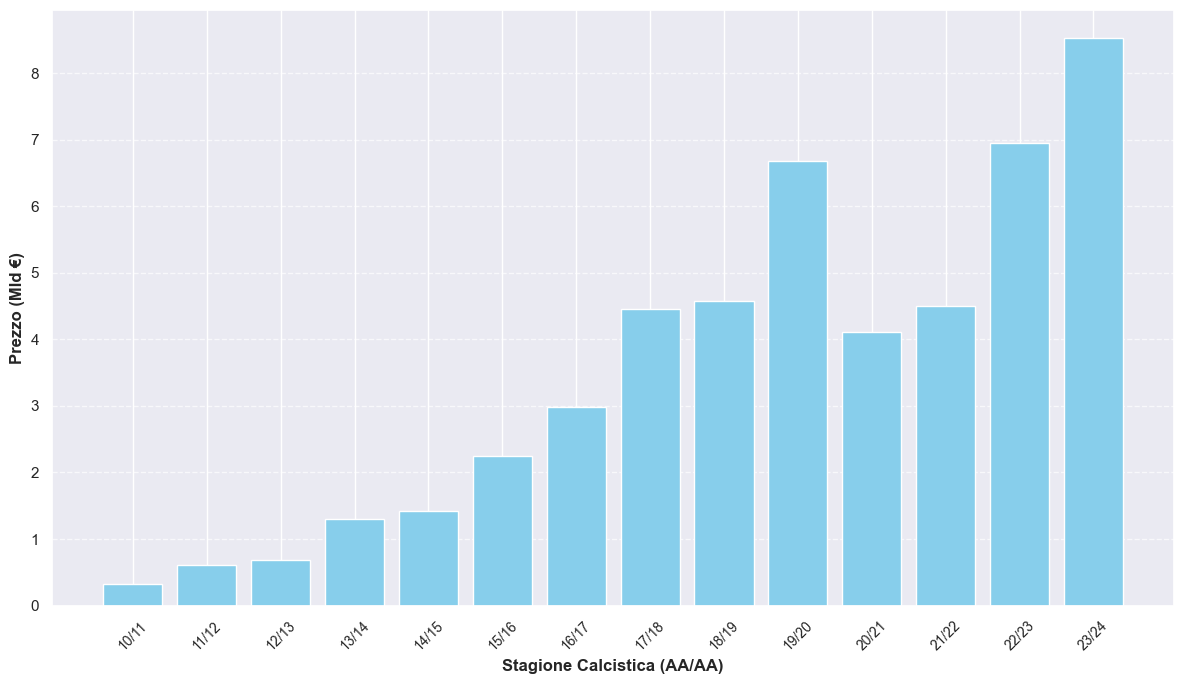

In [7]:
# ========================================================
#print("--- [GENERAZIONE GRAFICI DESCRITTIVI] ---")

#print("[GRAFICO 1]:\\Istogramma Spese Annuali")
plot_istogramma_spese(df_annuale, CART_GRAFICI)

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        1. Analisi del trend
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

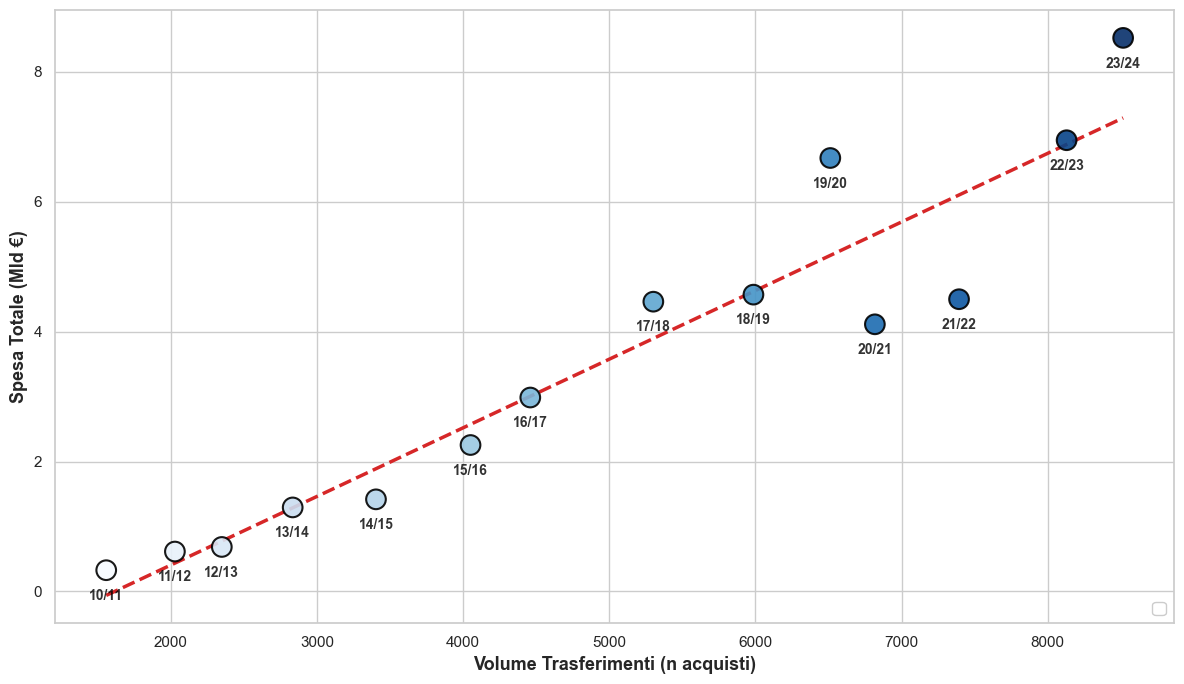

In [8]:
#print("[GRAFICO 3]:\\Grafico correlazione volume - spesa")
correlazione_volume_spesa(df_annuale, r_pearson, p_value, CART_GRAFICI)

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        2. Fattore età
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

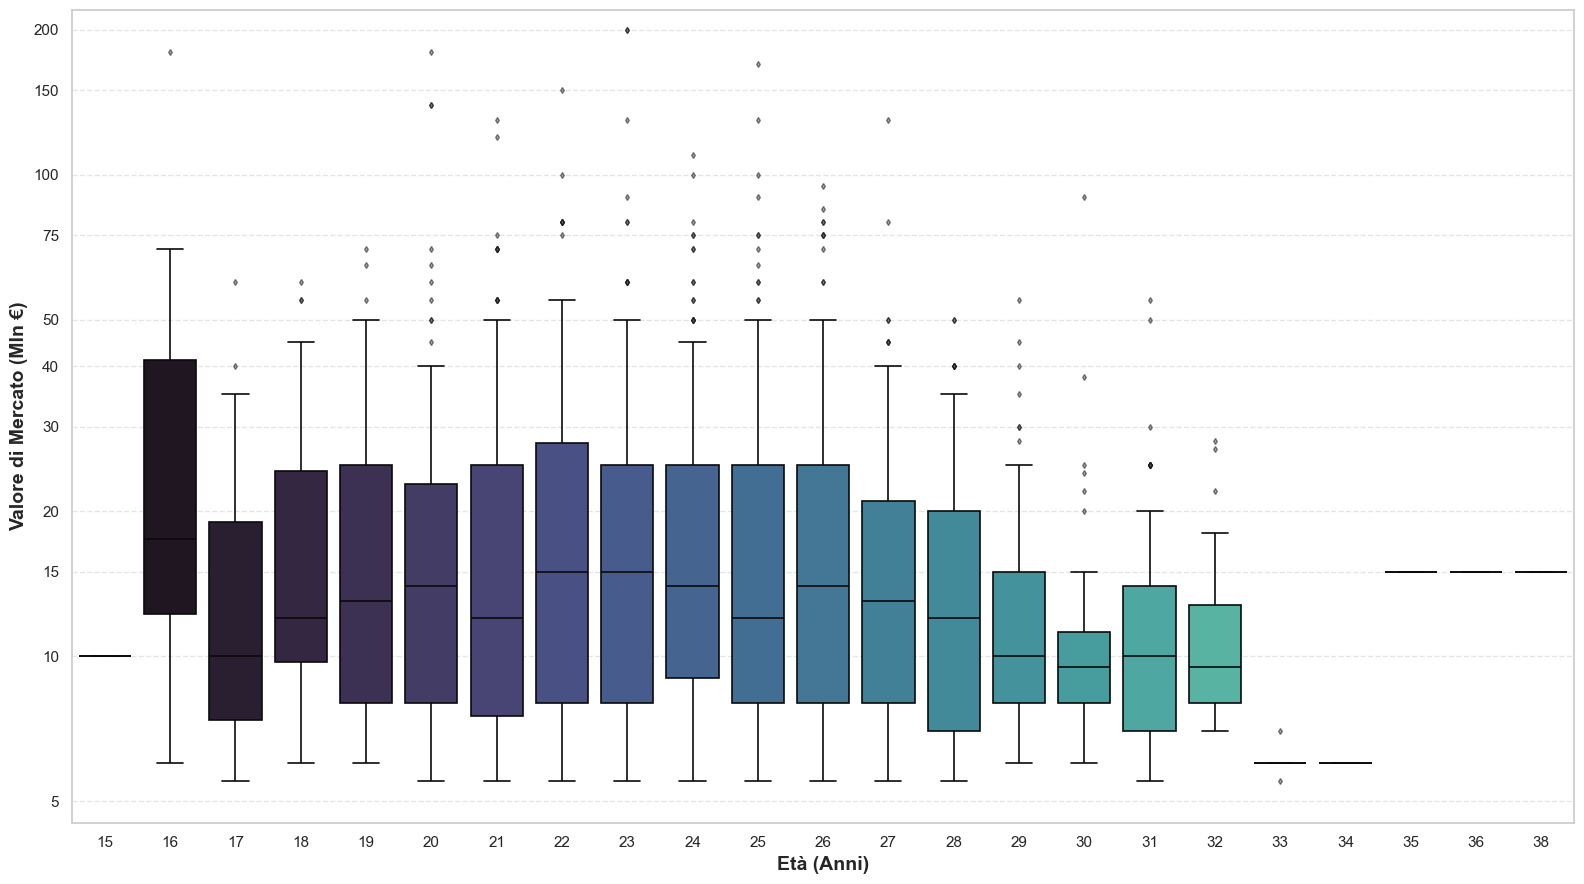

In [9]:
#print(f"="*80)
#print("\t\tANALISI VALORE GIOCATORI 23/24")
#print(f"="*80)

#print(f"[GRAFICO 8]:\\Distribuzione Valore per Età")
plot_distribuzione_eta_valore_totale(df_eta_pulito_totale, CART_GRAFICI) 

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        2. Fattore età
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

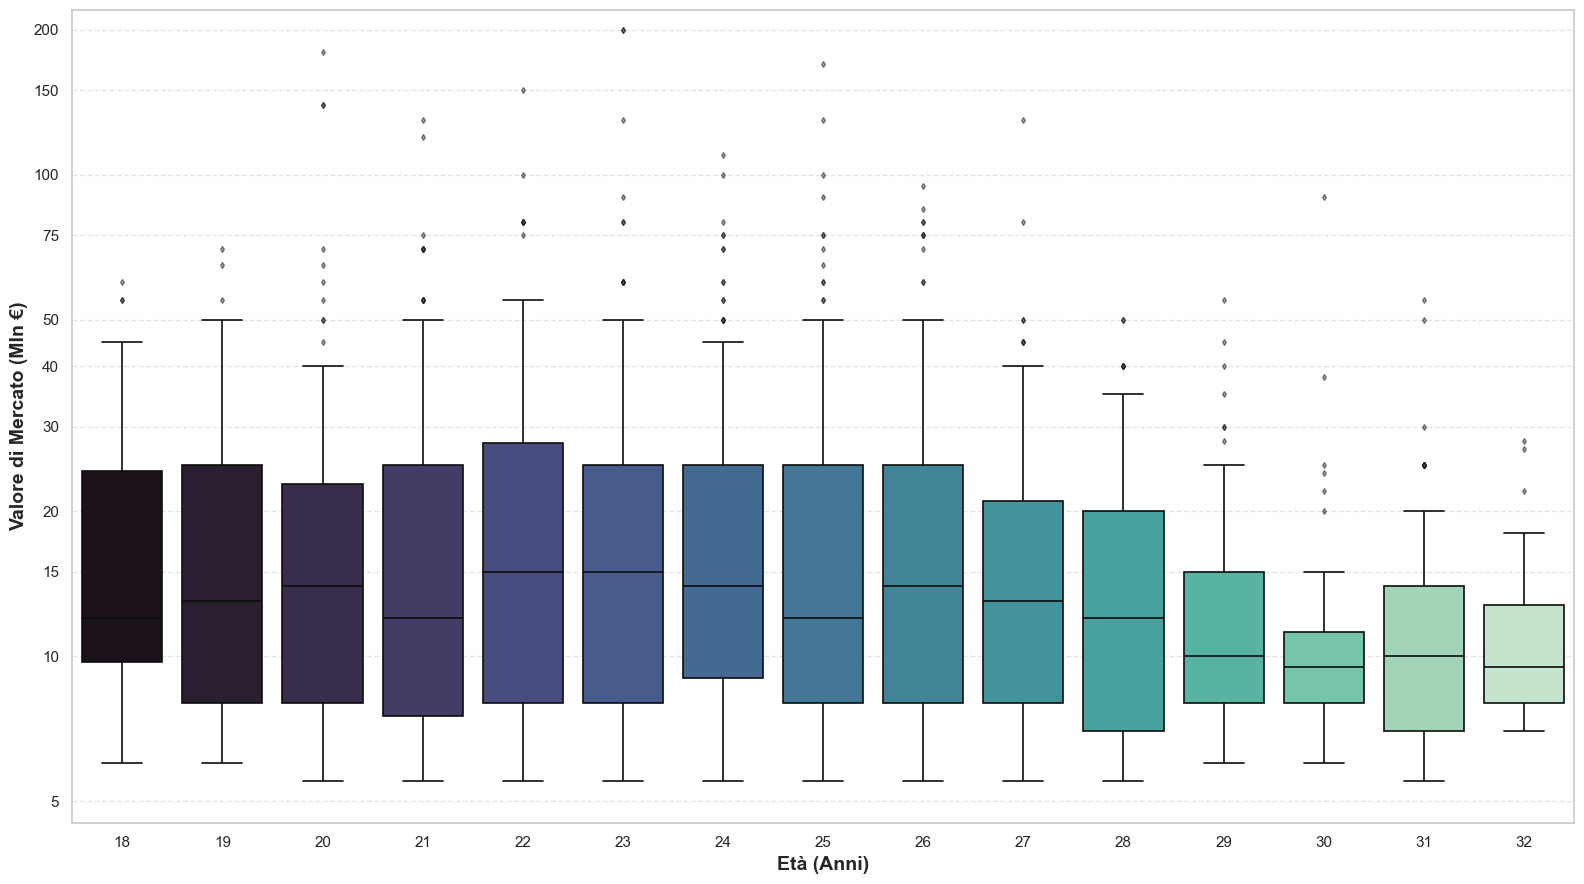

In [10]:
#print(f"="*80)
#print("\t\tANALISI VALORE GIOCATORI 23/24")
#print(f"="*80)

#print(f"[GRAFICO 8]:\\Distribuzione Valore per Età")
plot_distribuzione_eta_valore(df_eta_pulito, CART_GRAFICI) 

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        2. Fattore età
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

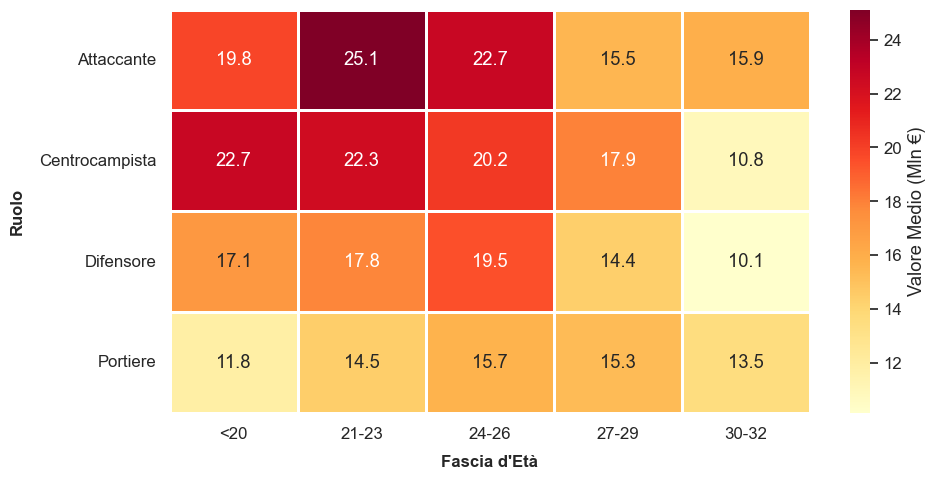

In [11]:
# 2. Generiamo il grafico
plot_heatmap(matrice_finale)

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        3. Valutazione dell'efficienza
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

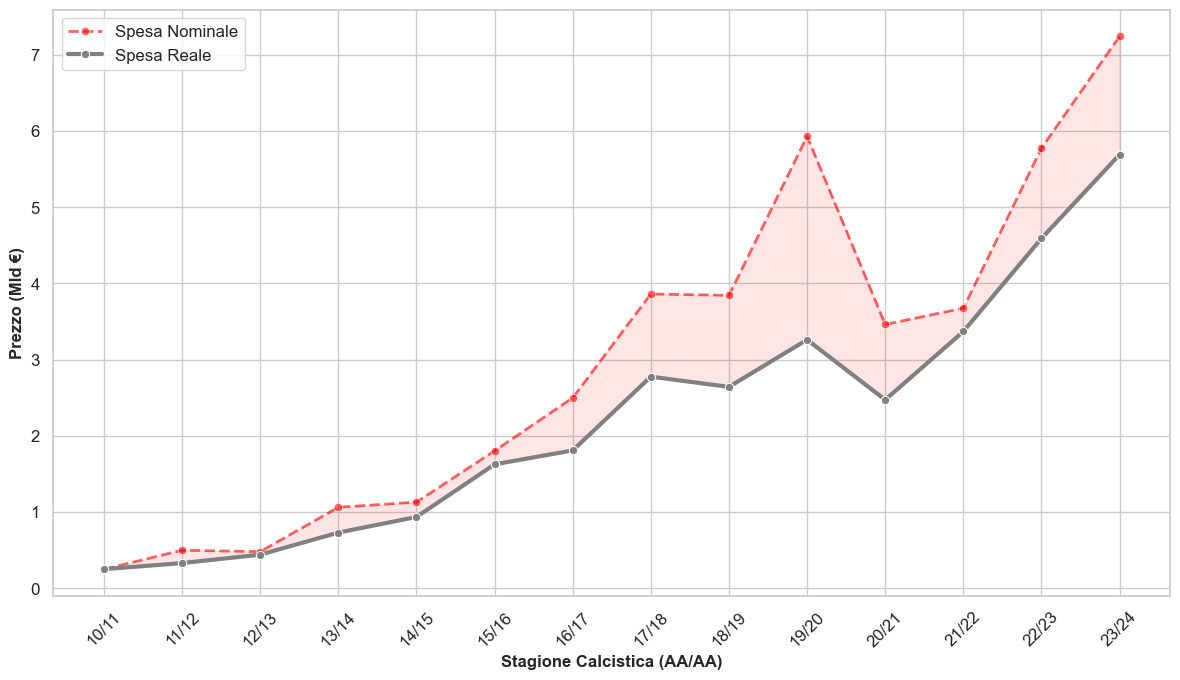

In [12]:
#print("[GRAFICO 2]:\\Confronto valori reali e valore ipotetico inflazione")
plot_confronto_nominale_reale(df_inflazionato, CART_GRAFICI)



<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        3. Valutazione dell'efficienza
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
    </div>
</div>

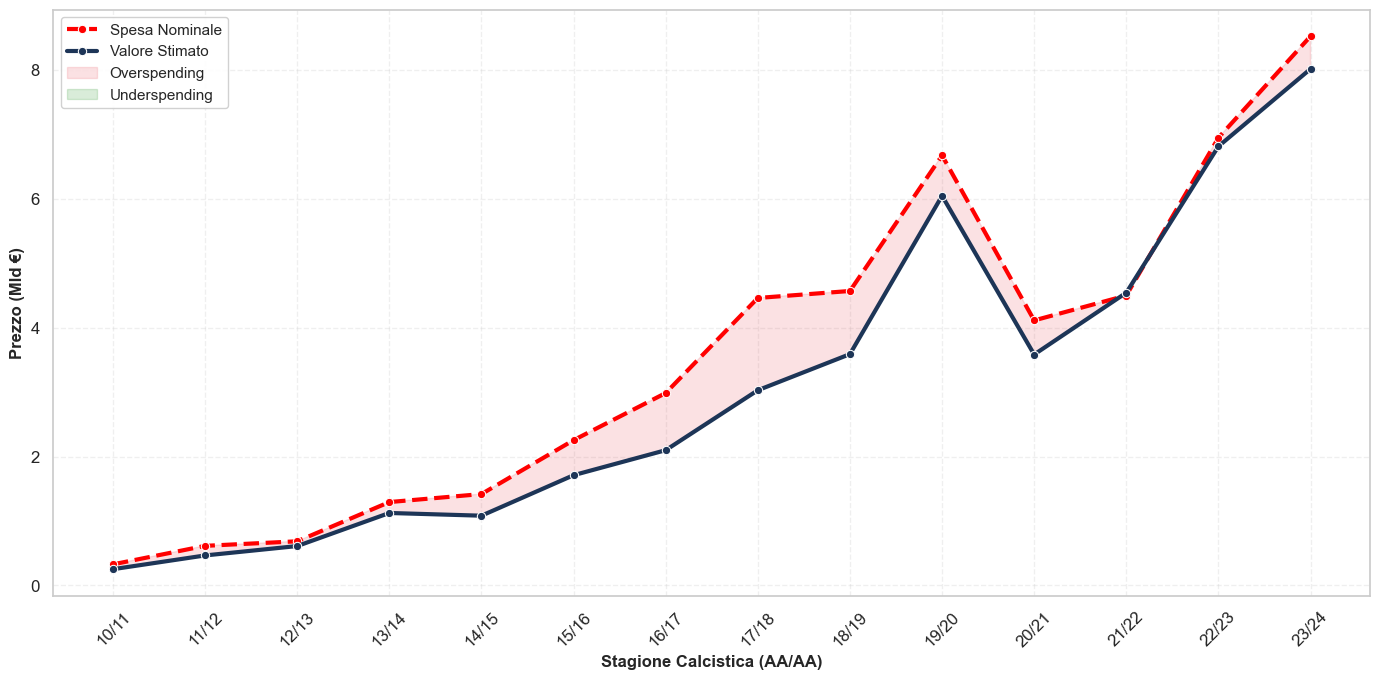

In [13]:
#print("[GRAFICO 4]:\\Grafico efficienza.")
plot_trend_efficienza(df_efficienza, CART_GRAFICI)

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        3. Valutazione dell'efficienza
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
        <p>Focus sull'anomalia</p>
    </div>
</div>

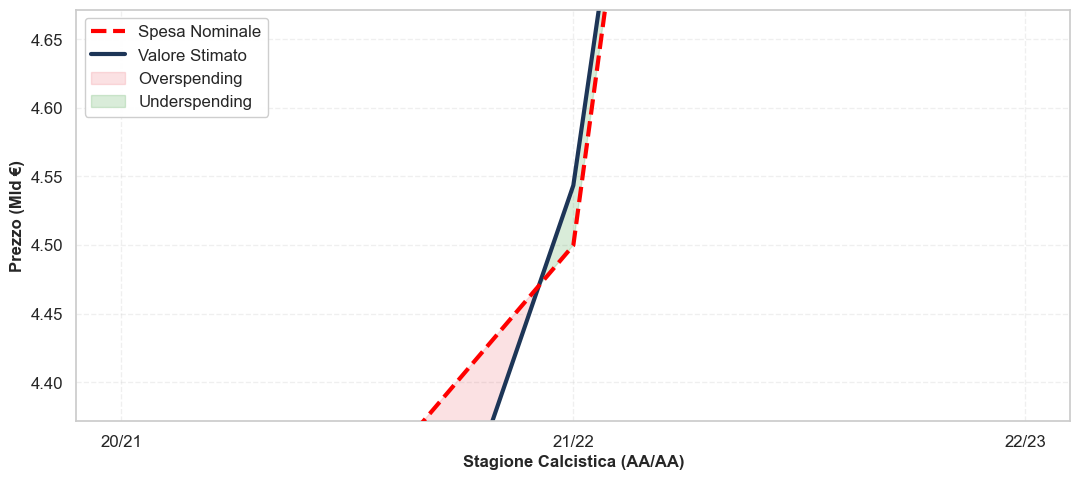

In [14]:
focus_AreaVerde(focusVerde(df_focus), CART_GRAFICI)

<div style="text-align: left; margin-top: 20px;">
    <h2 style="color: #2c3e50; font-size: 50px; margin-bottom: 30px; border-bottom: 3px solid #3498db; padding-bottom: 15px;">
        Conclusioni
    </h2>
    <div style="font-size: 26px; color: #34495e; line-height: 1.5;">
        <div style="margin-bottom: 30px;">
            <strong style="color: #2980b9; font-size: 30px; display: block; margin-bottom: 5px;">
                1. Espansione finanziaria
            </strong>
            Il mercato è in crescita strutturale costante.
        </div>
        <div style="margin-bottom: 30px;">
            <strong style="color: #2980b9; font-size: 30px; display: block; margin-bottom: 5px;">
                2. Costo potenziale
            </strong>
            L'età rappresenta la principale causa del prezzo elevato dei giocatori
        </div>
        <div style="margin-bottom: 30px;">
            <strong style="color: #2980b9; font-size: 30px; display: block; margin-bottom: 5px;">
                3. Valore sottostimato
            </strong>
            Le stime generali fatte risultano inferiori ai reali valori di mercato
        </div>
    </div>
</div>